# Import Libraries

In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.ml.clustering import KMeans
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import ClusteringEvaluator, MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.sql.functions import col, count, when
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

spark = SparkSession.builder.appName("FraudDetection").getOrCreate()

print("Libraries imported!")
print("Spark version:", spark.version)

Libraries imported!
Spark version: 4.1.1


# Load Dataset

In [ ]:
df = spark.read.csv("dataset/creditcard.csv", header=True, inferSchema=True)

print("Dataset shape:", df.count(), "rows x", len(df.columns), "columns")
print("\nColumns:", df.columns)
df.show(5)

Dataset shape: 284807 rows x 31 columns

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
+----+------------------+-------------------+----------------+------------------+-------------------+-------------------+-------------------+------------------+------------------+-------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+-------------------+--------------------+-------------------+------------------+------------------+------------------+------------------+--------------------+-------------------+------+-----+
|Time|                V1|                 V2|              V3|                V4|                 V5|                 V6|                 V7|                V8|            

# Data Exploration (สำรวจข้อมูล)

In [ ]:
print("=== Class Distribution (Fraud vs Normal) ===")
df.groupBy("Class").count().show()

fraud_count = df.filter(col("Class") == 1).count()
normal_count = df.filter(col("Class") == 0).count()
total = df.count()

print(f"Normal transactions: {normal_count} ({normal_count/total*100:.2f}%)")
print(f"Fraud transactions: {fraud_count} ({fraud_count/total*100:.2f}%)")
print(f"Fraud ratio: 1 : {normal_count//fraud_count}")

=== Class Distribution (Fraud vs Normal) ===
+-----+------+
|Class| count|
+-----+------+
|    1|   492|
|    0|284315|
+-----+------+

Normal transactions: 284315 (99.83%)
Fraud transactions: 492 (0.17%)
Fraud ratio: 1 : 577


# Visualization - Class Distribution

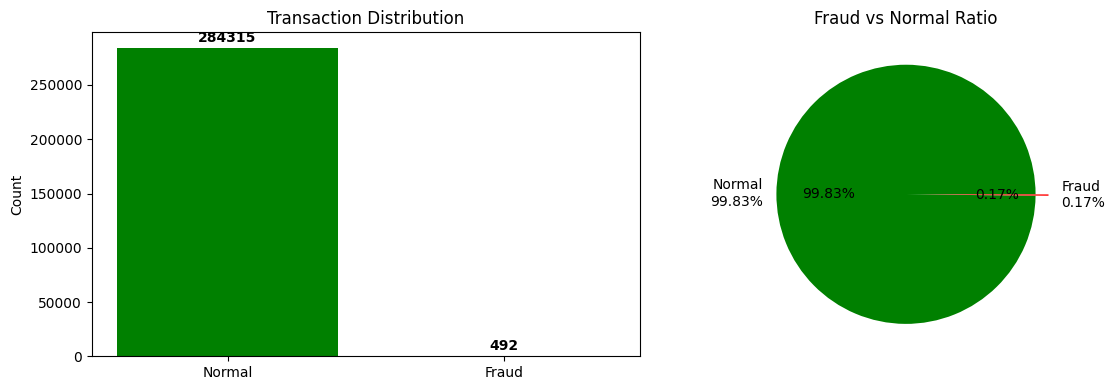

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
classes = ['Normal', 'Fraud']
counts = [normal_count, fraud_count]
colors = ['green', 'red']
plt.bar(classes, counts, color=colors)
plt.title('Transaction Distribution')
plt.ylabel('Count')
for i, v in enumerate(counts):
    plt.text(i, v + 5000, str(v), ha='center', fontweight='bold')

plt.subplot(1, 2, 2)
plt.pie([normal_count, fraud_count], labels=['Normal\n99.83%', 'Fraud\n0.17%'], 
        colors=colors, explode=[0, 0.1], autopct='%1.2f%%')
plt.title('Fraud vs Normal Ratio')

plt.tight_layout()
plt.show()

# Visualization - Amount Distribution

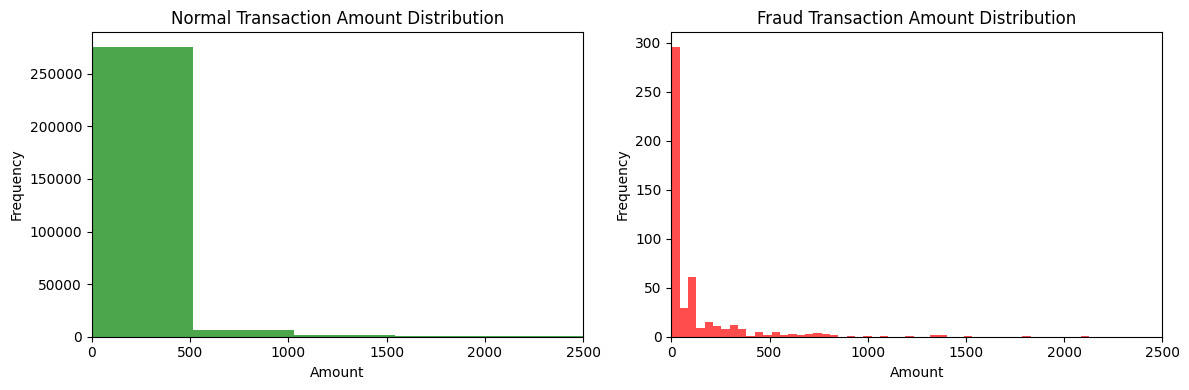

Normal - Mean Amount: $88.29
Fraud - Mean Amount: $122.21


In [ ]:
pdf = df.select("Amount", "Class").toPandas()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(pdf[pdf['Class'] == 0]['Amount'], bins=50, color='green', alpha=0.7, label='Normal')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.title('Normal Transaction Amount Distribution')
plt.xlim(0, 2500)

plt.subplot(1, 2, 2)
plt.hist(pdf[pdf['Class'] == 1]['Amount'], bins=50, color='red', alpha=0.7, label='Fraud')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.title('Fraud Transaction Amount Distribution')
plt.xlim(0, 2500)

plt.tight_layout()
plt.show()

print(f"Normal - Mean Amount: ${pdf[pdf['Class']==0]['Amount'].mean():.2f}")
print(f"Fraud - Mean Amount: ${pdf[pdf['Class']==1]['Amount'].mean():.2f}")

# Data Preprocessing - สร้าง Feature Vector

In [ ]:
feature_cols = ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
                'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
                'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']

assembler = VectorAssembler(inputCols=feature_cols, outputCol='features')
data = assembler.transform(df)

print("Feature vector created!")
print(f"Number of features: {len(feature_cols)}")
data.select('features', 'Class').show(3, truncate=False)

Feature vector created!
Number of features: 29
+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+
|features                                                                                                                                                                                                                                                                                                                                                                                                                          

# Standardize Features

In [ ]:
scaler = StandardScaler(inputCol='features', outputCol='scaled_features', withStd=True, withMean=True)

scaler_model = scaler.fit(data)
data_scaled = scaler_model.transform(data)

print("Features scaled!")
data_scaled.select('scaled_features', 'Class').show(3, truncate=50)

Features scaled!
+--------------------------------------------------+-----+
|                                   scaled_features|Class|
+--------------------------------------------------+-----+
|[-0.694241102163887,-0.044074847193551925,1.672...|    0|
|[0.6084952594310958,0.1611756369266399,0.109796...|    0|
|[-0.6934992452238209,-0.8115764015230561,1.1694...|    0|
+--------------------------------------------------+-----+
only showing top 3 rows


# PCA (ลดมิติเหลือ 2 สำหรับ Visualization)

In [ ]:
pca = PCA(k=2, inputCol='scaled_features', outputCol='pca_features')

pca_model = pca.fit(data_scaled)
data_pca = pca_model.transform(data_scaled)

print("=== PCA Results ===")
print(f"Explained Variance: {pca_model.explainedVariance.toArray()}")
print(f"Total Variance Retained: {sum(pca_model.explainedVariance.toArray()) * 100:.2f}%")

data_pca.select('pca_features', 'Class').show(3, truncate=False)

=== PCA Results ===
Explained Variance: [0.06751182 0.03448276]
Total Variance Retained: 10.20%
+------------------------------------------+-----+
|pca_features                              |Class|
+------------------------------------------+-----+
|[0.32370562743829745,-0.4554812386684258] |0    |
|[-0.4724154036330329,-0.3361920212847249] |0    |
|[1.7749757206770358,-0.007779494257510938]|0    |
+------------------------------------------+-----+
only showing top 3 rows


# PCA Visualization - Fraud vs Normal

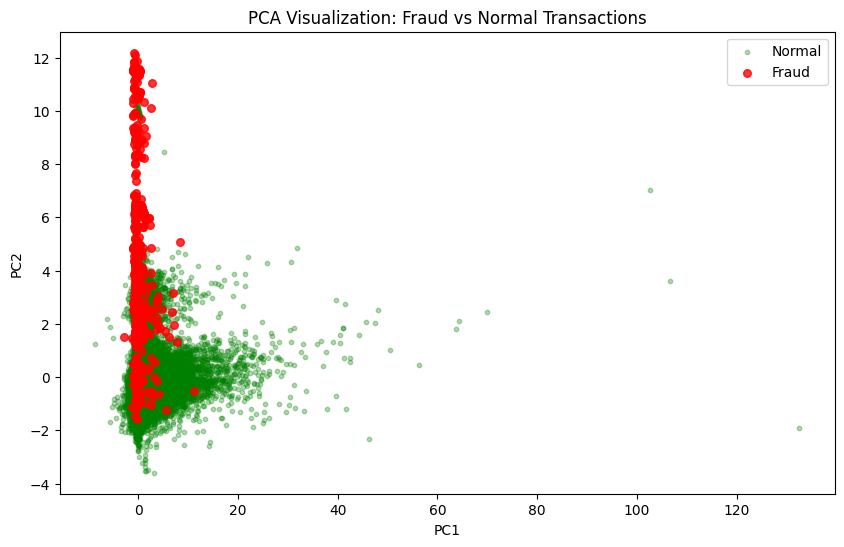

In [ ]:
pdf_pca = data_pca.select('pca_features', 'Class').toPandas()
pdf_pca['PC1'] = pdf_pca['pca_features'].apply(lambda x: x[0])
pdf_pca['PC2'] = pdf_pca['pca_features'].apply(lambda x: x[1])

plt.figure(figsize=(10, 6))

normal = pdf_pca[pdf_pca['Class'] == 0]
fraud = pdf_pca[pdf_pca['Class'] == 1]

plt.scatter(normal['PC1'], normal['PC2'], c='green', alpha=0.3, label='Normal', s=10)
plt.scatter(fraud['PC1'], fraud['PC2'], c='red', alpha=0.8, label='Fraud', s=30)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Visualization: Fraud vs Normal Transactions')
plt.legend()
plt.show()

# K-Means Clustering

In [ ]:
kmeans = KMeans(k=3, seed=42, featuresCol='scaled_features', predictionCol='cluster')

kmeans_model = kmeans.fit(data_scaled)
data_clustered = kmeans_model.transform(data_scaled)

print("=== K-Means Clustering Results ===")
print("\nCluster Distribution:")
data_clustered.groupBy('cluster').count().orderBy('cluster').show()

print("\nCluster vs Fraud Analysis:")
data_clustered.groupBy('cluster', 'Class').count().orderBy('cluster', 'Class').show()

=== K-Means Clustering Results ===

Cluster Distribution:
+-------+------+
|cluster| count|
+-------+------+
|      0|131917|
|      1| 77067|
|      2| 75823|
+-------+------+


Cluster vs Fraud Analysis:
+-------+-----+------+
|cluster|Class| count|
+-------+-----+------+
|      0|    0|131868|
|      0|    1|    49|
|      1|    0| 76863|
|      1|    1|   204|
|      2|    0| 75584|
|      2|    1|   239|
+-------+-----+------+



# K-Means Evaluation & Visualization

=== K-Means Evaluation ===
Silhouette Score: 0.0261
WSSSE: 7864329.16

=== Fraud Rate per Cluster ===
   cluster   total  fraud_count  fraud_rate
0        0  131917           49    0.037145
1        1   77067          204    0.264705
2        2   75823          239    0.315208


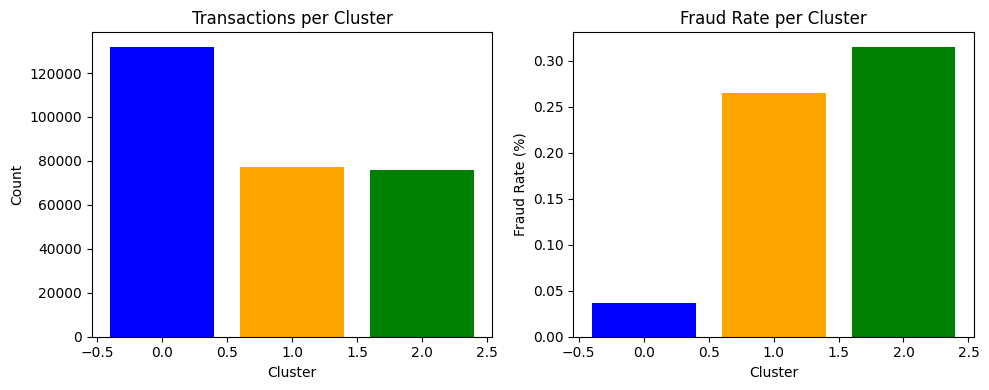

In [ ]:
evaluator = ClusteringEvaluator(featuresCol='scaled_features', predictionCol='cluster', metricName='silhouette')
silhouette = evaluator.evaluate(data_clustered)

print(f"=== K-Means Evaluation ===")
print(f"Silhouette Score: {silhouette:.4f}")
print(f"WSSSE: {kmeans_model.summary.trainingCost:.2f}")

print("\n=== Fraud Rate per Cluster ===")
cluster_stats = data_clustered.groupBy('cluster').agg(
    count('*').alias('total'),
    count(when(col('Class') == 1, 1)).alias('fraud_count')
).orderBy('cluster').toPandas()

cluster_stats['fraud_rate'] = cluster_stats['fraud_count'] / cluster_stats['total'] * 100
print(cluster_stats)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.bar(cluster_stats['cluster'], cluster_stats['total'], color=['blue', 'orange', 'green'])
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.title('Transactions per Cluster')

plt.subplot(1, 2, 2)
plt.bar(cluster_stats['cluster'], cluster_stats['fraud_rate'], color=['blue', 'orange', 'green'])
plt.xlabel('Cluster')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate per Cluster')

plt.tight_layout()
plt.show()

# Classification - Random Forest (ทำนาย Fraud)

In [ ]:
train_data, test_data = data_scaled.randomSplit([0.8, 0.2], seed=42)

print(f"Training set: {train_data.count()} rows")
print(f"Test set: {test_data.count()} rows")

rf = RandomForestClassifier(
    featuresCol='scaled_features',
    labelCol='Class',
    predictionCol='prediction',
    numTrees=100,
    maxDepth=10,
    seed=42
)

print("\nTraining Random Forest... (อาจใช้เวลา 1-2 นาที)")
rf_model = rf.fit(train_data)
print("Model trained!")

predictions = rf_model.transform(test_data)
predictions.select('Class', 'prediction', 'probability').show(10)

Training set: 228162 rows
Test set: 56645 rows

Training Random Forest... (อาจใช้เวลา 1-2 นาที)
Model trained!
+-----+----------+--------------------+
|Class|prediction|         probability|
+-----+----------+--------------------+
|    0|       0.0|[0.99982886942676...|
|    0|       0.0|[0.99994438099167...|
|    0|       0.0|[0.99995719004238...|
|    0|       0.0|[0.99982754672116...|
|    0|       0.0|[0.99994926893302...|
|    0|       0.0|[0.99980661796620...|
|    0|       0.0|[0.99993019788188...|
|    0|       0.0|[0.99995740329692...|
|    0|       0.0|[0.99995426272245...|
|    0|       0.0|[0.99995312237298...|
+-----+----------+--------------------+
only showing top 10 rows


# Model Evaluation

In [ ]:
evaluator_acc = MulticlassClassificationEvaluator(labelCol='Class', predictionCol='prediction', metricName='accuracy')
evaluator_precision = MulticlassClassificationEvaluator(labelCol='Class', predictionCol='prediction', metricName='weightedPrecision')
evaluator_recall = MulticlassClassificationEvaluator(labelCol='Class', predictionCol='prediction', metricName='weightedRecall')
evaluator_f1 = MulticlassClassificationEvaluator(labelCol='Class', predictionCol='prediction', metricName='f1')
evaluator_auc = BinaryClassificationEvaluator(labelCol='Class', rawPredictionCol='rawPrediction', metricName='areaUnderROC')

accuracy = evaluator_acc.evaluate(predictions)
precision = evaluator_precision.evaluate(predictions)
recall = evaluator_recall.evaluate(predictions)
f1 = evaluator_f1.evaluate(predictions)
auc = evaluator_auc.evaluate(predictions)

print("=" * 50)
print("        RANDOM FOREST MODEL EVALUATION")
print("=" * 50)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")
print("=" * 50)

        RANDOM FOREST MODEL EVALUATION
Accuracy:  0.9993 (99.93%)
Precision: 0.9993
Recall:    0.9993
F1 Score:  0.9993
AUC-ROC:   0.9729


# Confusion Matrix

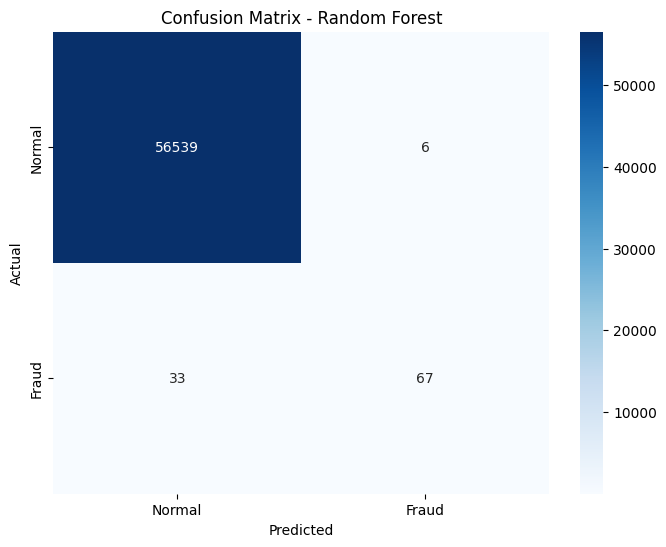


=== Classification Report ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56545
       Fraud       0.92      0.67      0.77       100

    accuracy                           1.00     56645
   macro avg       0.96      0.83      0.89     56645
weighted avg       1.00      1.00      1.00     56645



In [ ]:
pred_pd = predictions.select('Class', 'prediction').toPandas()

from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(pred_pd['Class'], pred_pd['prediction'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Fraud'], 
            yticklabels=['Normal', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

print("\n=== Classification Report ===")
print(classification_report(pred_pd['Class'], pred_pd['prediction'], 
                            target_names=['Normal', 'Fraud']))

# Feature Importance

=== Top 10 Most Important Features ===
   feature  importance
11     V12    0.135172
16     V17    0.114742
6       V7    0.081061
15     V16    0.071961
9      V10    0.065498
8       V9    0.060564
13     V14    0.059704
3       V4    0.053811
10     V11    0.048249
17     V18    0.034876


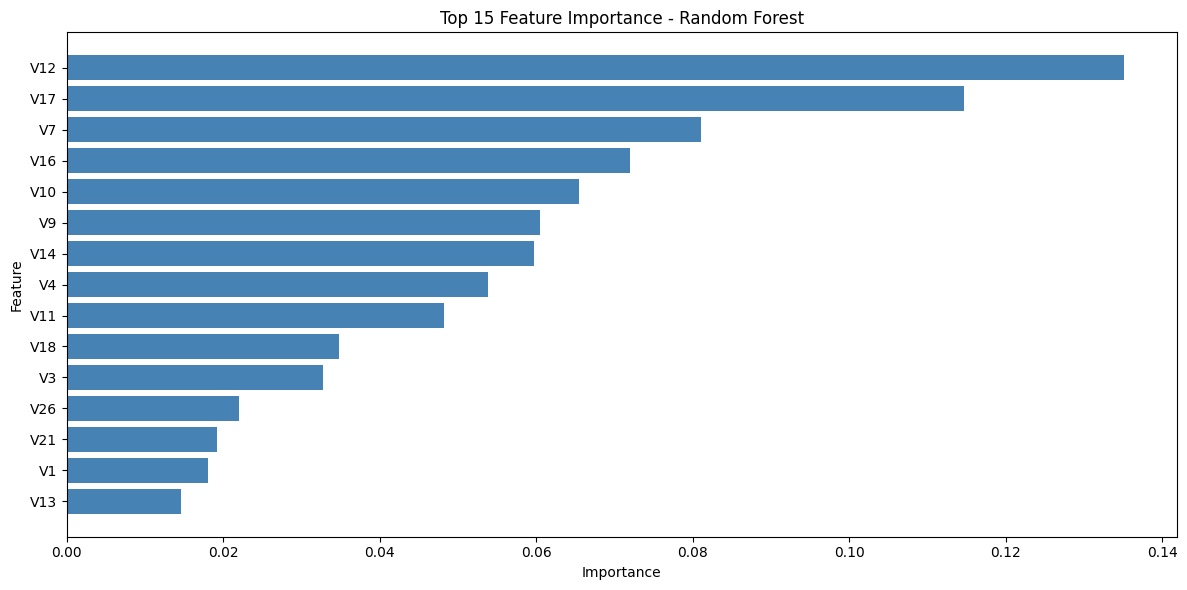

In [ ]:
feature_importance = rf_model.featureImportances.toArray()

feature_imp_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("=== Top 10 Most Important Features ===")
print(feature_imp_df.head(10))

plt.figure(figsize=(12, 6))
top_features = feature_imp_df.head(15)
plt.barh(top_features['feature'], top_features['importance'], color='steelblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 15 Feature Importance - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Summary - สรุปผลทั้งหมด

In [ ]:
print("=" * 60)
print("       MINI PROJECT: CREDIT CARD FRAUD DETECTION")
print("                    SUMMARY REPORT")
print("=" * 60)

print("\nDATASET OVERVIEW")
print("-" * 60)
print(f"Total Transactions:     {total:,}")
print(f"Normal Transactions:    {normal_count:,} ({normal_count/total*100:.2f}%)")
print(f"Fraud Transactions:     {fraud_count:,} ({fraud_count/total*100:.2f}%)")
print(f"Number of Features:     {len(feature_cols)}")

print("\nPCA RESULTS")
print("-" * 60)
print(f"Components:             2")
print(f"Variance Retained:      {sum(pca_model.explainedVariance.toArray())*100:.2f}%")

print("\nK-MEANS CLUSTERING")
print("-" * 60)
print(f"Number of Clusters:     3")
print(f"Silhouette Score:       {silhouette:.4f}")
print(f"Cluster 0 Fraud Rate:   {cluster_stats.iloc[0]['fraud_rate']:.4f}%")
print(f"Cluster 1 Fraud Rate:   {cluster_stats.iloc[1]['fraud_rate']:.4f}%")
print(f"Cluster 2 Fraud Rate:   {cluster_stats.iloc[2]['fraud_rate']:.4f}%")

print("\nRANDOM FOREST CLASSIFICATION")
print("-" * 60)
print(f"Accuracy:               {accuracy*100:.2f}%")
print(f"Precision:              {precision:.4f}")
print(f"Recall:                 {recall:.4f}")
print(f"F1 Score:               {f1:.4f}")
print(f"AUC-ROC:                {auc:.4f}")

print("\nTOP 5 IMPORTANT FEATURES")
print("-" * 60)
for i, row in feature_imp_df.head(5).iterrows():
    print(f"{row['feature']:>10}: {row['importance']:.4f}")

print("\n" + "=" * 60)
print("                    END OF REPORT")
print("=" * 60)

       MINI PROJECT: CREDIT CARD FRAUD DETECTION
                    SUMMARY REPORT

DATASET OVERVIEW
------------------------------------------------------------
Total Transactions:     284,807
Normal Transactions:    284,315 (99.83%)
Fraud Transactions:     492 (0.17%)
Number of Features:     29

PCA RESULTS
------------------------------------------------------------
Components:             2
Variance Retained:      10.20%

K-MEANS CLUSTERING
------------------------------------------------------------
Number of Clusters:     3
Silhouette Score:       0.0261
Cluster 0 Fraud Rate:   0.0371%
Cluster 1 Fraud Rate:   0.2647%
Cluster 2 Fraud Rate:   0.3152%

RANDOM FOREST CLASSIFICATION
------------------------------------------------------------
Accuracy:               99.93%
Precision:              0.9993
Recall:                 0.9993
F1 Score:               0.9993
AUC-ROC:                0.9729

TOP 5 IMPORTANT FEATURES
------------------------------------------------------------
   